In [1]:
import torch
from pathlib import Path
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split

In [2]:
# Set the configuration for reproducibility
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd().parent
DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "magnetic_tile"

In [4]:
# Load the JPG files only, for making defect classification model

classes = sorted([d.name for d in DATASET_PATH.iterdir() if d.is_dir()])
class_to_idx = {cls: i for i, cls in enumerate(classes)}

image_paths = []
labels = []

for cls in classes:
    image_folder = DATASET_PATH / cls / "Imgs"

    for path in image_folder.glob("*.jpg"):
        image_paths.append(path)
        labels.append(class_to_idx[cls])

print(classes)
print(len(image_paths))

['MT_Blowhole', 'MT_Break', 'MT_Crack', 'MT_Fray', 'MT_Free', 'MT_Uneven']
1344


In [5]:
# Let us split the data into train-validation-test data
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

In [6]:
from collections import Counter

print("Train:", Counter(train_labels))
print("Val:  ", Counter(val_labels))
print("Test: ", Counter(test_labels))

Train: Counter({4: 666, 0: 80, 5: 72, 1: 60, 2: 40, 3: 22})
Val:   Counter({4: 143, 0: 17, 5: 16, 1: 13, 2: 8, 3: 5})
Test:  Counter({4: 143, 0: 18, 5: 15, 1: 12, 2: 9, 3: 5})


`Consistent data overall`

In [9]:
# Transform Validation/Test images
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

## Experiment A : No Data Augmentation

In [8]:
# Training data transformation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomVerticalFlip(),
    # transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [10]:
# Dataset class
class MagneticTileDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("L")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
# Generate datasets
train_dataset = MagneticTileDataset(
    train_paths,
    train_labels,
    train_transform
)

val_dataset = MagneticTileDataset(
    val_paths,
    val_labels,
    val_test_transform
)

test_dataset = MagneticTileDataset(
    test_paths,
    test_labels,
    val_test_transform
)

In [24]:
# Generate DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # NO NEED TO SHUFFLE Validation and Test data
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [25]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Images: torch.Size([32, 1, 224, 224])
Labels: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64


In [26]:
# Define Baseline CNN Model
import torch
import torch.nn as nn


class BaselineCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [27]:
# Using GPU to train the model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Train Model Function

In [16]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    save_path="best_model.pth"
):
    best_val_loss = float("inf")

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        # Training
        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            train_correct += (predictions == labels).sum().item()
            train_total += labels.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        # Validation
        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                predictions = outputs.argmax(dim=1)
                val_correct += (predictions == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        # Store history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                model.state_dict(),
                save_path
            )

    return history

### Evaluate Model Function

In [28]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    matthews_corrcoef
)


def evaluate_model(
    model,
    test_loader,
    device,
    classes
):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1).cpu()

            all_predictions.extend(predictions.numpy())
            all_labels.extend(labels.numpy())

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        all_labels,
        all_predictions
    )

    mcc = matthews_corrcoef(
        all_labels,
        all_predictions
    )

    print(f"Accuracy:          {accuracy:.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
    print(f"MCC:               {mcc:.4f}")

    print("\nClassification Report:\n")

    print(
        classification_report(
            all_labels,
            all_predictions,
            target_names=classes,
            digits=4
        )
    )

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "mcc": mcc,
        "labels": all_labels,
        "predictions": all_predictions
    }

**Experiment A -> No data augmentation**

In [29]:
model_A = BaselineCNN(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_A.parameters(),
    lr=1e-3
)

In [30]:
# Train Model A
history_A = train_model(
    model=model_A,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    save_path="baseline_no_aug.pth"
)

Epoch [1/10] | Train Loss: 1.2595 | Train Acc: 0.6585 | Val Loss: 1.0516 | Val Acc: 0.7079
Epoch [2/10] | Train Loss: 1.0581 | Train Acc: 0.7085 | Val Loss: 1.0670 | Val Acc: 0.7079
Epoch [3/10] | Train Loss: 1.0621 | Train Acc: 0.7085 | Val Loss: 1.0647 | Val Acc: 0.7079
Epoch [4/10] | Train Loss: 1.0564 | Train Acc: 0.7085 | Val Loss: 1.0784 | Val Acc: 0.7079
Epoch [5/10] | Train Loss: 1.0557 | Train Acc: 0.7085 | Val Loss: 1.0734 | Val Acc: 0.7079
Epoch [6/10] | Train Loss: 1.0557 | Train Acc: 0.7085 | Val Loss: 1.0826 | Val Acc: 0.7079
Epoch [7/10] | Train Loss: 1.0477 | Train Acc: 0.7085 | Val Loss: 1.0877 | Val Acc: 0.7079
Epoch [8/10] | Train Loss: 1.0467 | Train Acc: 0.7085 | Val Loss: 1.0700 | Val Acc: 0.7079
Epoch [9/10] | Train Loss: 1.0476 | Train Acc: 0.7085 | Val Loss: 1.0632 | Val Acc: 0.7079
Epoch [10/10] | Train Loss: 1.0545 | Train Acc: 0.7085 | Val Loss: 1.0756 | Val Acc: 0.7079


In [31]:
# Load the best checkpoint
model_A.load_state_dict(
    torch.load(
        "baseline_no_aug.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [32]:
# Evaluate Model A

results_A = evaluate_model(
    model_A,
    test_loader,
    device,
    classes
)

Accuracy:          0.7079
Balanced Accuracy: 0.1667
MCC:               0.0000

Classification Report:

              precision    recall  f1-score   support

 MT_Blowhole     0.0000    0.0000    0.0000        18
    MT_Break     0.0000    0.0000    0.0000        12
    MT_Crack     0.0000    0.0000    0.0000         9
     MT_Fray     0.0000    0.0000    0.0000         5
     MT_Free     0.7079    1.0000    0.8290       143
   MT_Uneven     0.0000    0.0000    0.0000        15

    accuracy                         0.7079       202
   macro avg     0.1180    0.1667    0.1382       202
weighted avg     0.5012    0.7079    0.5869       202



d:\Study\Deep_Learning\Pytorch_Course\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Study\Deep_Learning\Pytorch_Course\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Study\Deep_Learning\Pytorch_Course\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

`Experiment A — No Augmentation: Observation`

- The baseline CNN achieved 70.79% accuracy, but this performance is misleading because the model completely collapsed to the majority class, MT_Free. It correctly identified all MT_Free samples but failed to detect any of the five defect classes. This is reflected in the very low balanced accuracy (16.67%), macro F1-score (0.1382), and MCC (0.0000). Therefore, the unaugmented baseline demonstrates that the severe class imbalance prevents the simple CNN from learning meaningful representations of the minority defect classes.

**Experiment B -> Using Data Augmentation**

In [33]:
# training Data Transformation
train_transform_all_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [34]:
# Test and Validation data Augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [35]:
# Datasets for Experiment B
train_dataset_B = MagneticTileDataset(
    train_paths,
    train_labels,
    transform=train_transform_all_aug
)

val_dataset_B = MagneticTileDataset(
    val_paths,
    val_labels,
    transform=val_test_transform
)

test_dataset_B = MagneticTileDataset(
    test_paths,
    test_labels,
    transform=val_test_transform
)

In [37]:
# Creating DataLoaders
train_loader_B = DataLoader(
    train_dataset_B,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader_B = DataLoader(
    val_dataset_B,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader_B = DataLoader(
    test_dataset_B,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
images, labels = next(iter(train_loader_B))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 1, 224, 224])
Labels: torch.Size([32])


In [39]:
# New Model fot Experiment B
model_B = BaselineCNN(num_classes=6).to(device)

criterion_B = nn.CrossEntropyLoss()

optimizer_B = torch.optim.Adam(
    model_B.parameters(),
    lr=1e-3
)

In [40]:
# Train experiment
history_B = train_model(
    model=model_B,
    train_loader=train_loader_B,
    val_loader=val_loader_B,
    criterion=criterion_B,
    optimizer=optimizer_B,
    device=device,
    epochs=10,
    save_path="baseline_all_aug.pth"
)

Epoch [1/10] | Train Loss: 1.1964 | Train Acc: 0.6872 | Val Loss: 1.0524 | Val Acc: 0.7079
Epoch [2/10] | Train Loss: 1.0644 | Train Acc: 0.7085 | Val Loss: 1.0697 | Val Acc: 0.7079
Epoch [3/10] | Train Loss: 1.0590 | Train Acc: 0.7085 | Val Loss: 1.0674 | Val Acc: 0.7079
Epoch [4/10] | Train Loss: 1.0599 | Train Acc: 0.7085 | Val Loss: 1.0716 | Val Acc: 0.7079
Epoch [5/10] | Train Loss: 1.0550 | Train Acc: 0.7085 | Val Loss: 1.0721 | Val Acc: 0.7079
Epoch [6/10] | Train Loss: 1.0556 | Train Acc: 0.7085 | Val Loss: 1.0714 | Val Acc: 0.7079
Epoch [7/10] | Train Loss: 1.0479 | Train Acc: 0.7085 | Val Loss: 1.0754 | Val Acc: 0.7079
Epoch [8/10] | Train Loss: 1.0519 | Train Acc: 0.7085 | Val Loss: 1.0815 | Val Acc: 0.7079
Epoch [9/10] | Train Loss: 1.0592 | Train Acc: 0.7085 | Val Loss: 1.0735 | Val Acc: 0.7079
Epoch [10/10] | Train Loss: 1.0608 | Train Acc: 0.7085 | Val Loss: 1.0905 | Val Acc: 0.7079


In [41]:
# Load the best model 
model_B.load_state_dict(
    torch.load(
        "baseline_all_aug.pth",
        map_location=device
    )
)

model_B.to(device)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=6, bias=True)
  )
)

In [42]:
# Evaluate Experiment B
results_B = evaluate_model(
    model_B,
    test_loader_B,
    device,
    classes
)

Accuracy:          0.7079
Balanced Accuracy: 0.1667
MCC:               0.0000

Classification Report:

              precision    recall  f1-score   support

 MT_Blowhole     0.0000    0.0000    0.0000        18
    MT_Break     0.0000    0.0000    0.0000        12
    MT_Crack     0.0000    0.0000    0.0000         9
     MT_Fray     0.0000    0.0000    0.0000         5
     MT_Free     0.7079    1.0000    0.8290       143
   MT_Uneven     0.0000    0.0000    0.0000        15

    accuracy                         0.7079       202
   macro avg     0.1180    0.1667    0.1382       202
weighted avg     0.5012    0.7079    0.5869       202



d:\Study\Deep_Learning\Pytorch_Course\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Study\Deep_Learning\Pytorch_Course\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Study\Deep_Learning\Pytorch_Course\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

`There is No change in the result after Data Augmentation`
- This shows that the data is highly imbalanced, and since we augmented all the classes(including MT_Free) that eventually there was no change in the imbalance after Data Augmentation as well

**Experiment C -> Only Augment Defect Classes Using Class Weights**

In [59]:
train_transform_defect = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_transform_free = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [60]:
class MagneticTileDatasetC(Dataset):

    def __init__(
        self,
        image_paths,
        labels,
        transform_defect,
        transform_free
    ):
        self.image_paths = image_paths
        self.labels = labels
        self.transform_defect = transform_defect
        self.transform_free = transform_free

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image = Image.open(
            self.image_paths[idx]
        ).convert("L")

        label = self.labels[idx]

        # MT_Free is class index 4
        if label == class_to_idx["MT_Free"]:
            image = self.transform_free(image)
        else:
            image = self.transform_defect(image)

        return image, label

In [61]:
train_dataset_C = MagneticTileDatasetC(
    train_paths,
    train_labels,
    transform_defect=train_transform_defect,
    transform_free=train_transform_free
)

In [62]:
from collections import Counter
from torch.utils.data import WeightedRandomSampler

class_counts = Counter(train_labels)

print("Original training distribution:")
print(class_counts)

sample_weights = torch.tensor(
    [1 / class_counts[label] for label in train_labels],
    dtype=torch.double
)

sampler_C = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_labels),
    replacement=True
)

Original training distribution:
Counter({4: 666, 0: 80, 5: 72, 1: 60, 2: 40, 3: 22})


`give each class a sampling weight inversely proportional to its frequency`
- This means minority defect samples have a much higher probability of being selected.

In [63]:
train_loader_C = DataLoader(
    train_dataset_C,
    batch_size=BATCH_SIZE,
    sampler=sampler_C,
    num_workers=0,
    pin_memory=False
)

val_loader_C = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader_C = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(train_loader_C))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 1, 224, 224])
Labels: torch.Size([32])


- We used Weighted sampling, so that there are high chances of training sample to be from defect class rather than MT_FREE

In [64]:
sampled_labels = []

for _, labels in train_loader_C:
    sampled_labels.extend(labels.tolist())

print("Sampled distribution:")
print(Counter(sampled_labels))

Sampled distribution:
Counter({1: 184, 3: 169, 5: 152, 0: 152, 4: 145, 2: 138})


In [65]:
model_C = BaselineCNN(num_classes=6).to(device)

criterion_C = nn.CrossEntropyLoss()

optimizer_C = torch.optim.Adam(
    model_C.parameters(),
    lr=1e-3
)

In [66]:
history_C = train_model(
    model=model_C,
    train_loader=train_loader_C,
    val_loader=val_loader_C,
    criterion=criterion_C,
    optimizer=optimizer_C,
    device=device,
    epochs=10,
    save_path="baseline_defect_aug_oversampled.pth"
)

Epoch [1/10] | Train Loss: 1.7796 | Train Acc: 0.1904 | Val Loss: 1.9266 | Val Acc: 0.0446
Epoch [2/10] | Train Loss: 1.7786 | Train Acc: 0.1936 | Val Loss: 1.7776 | Val Acc: 0.2822
Epoch [3/10] | Train Loss: 1.7521 | Train Acc: 0.2489 | Val Loss: 1.8469 | Val Acc: 0.1139
Epoch [4/10] | Train Loss: 1.7488 | Train Acc: 0.2372 | Val Loss: 2.0627 | Val Acc: 0.1832
Epoch [5/10] | Train Loss: 1.7252 | Train Acc: 0.2713 | Val Loss: 1.5755 | Val Acc: 0.5495
Epoch [6/10] | Train Loss: 1.6500 | Train Acc: 0.3383 | Val Loss: 1.3479 | Val Acc: 0.6386
Epoch [7/10] | Train Loss: 1.6008 | Train Acc: 0.3266 | Val Loss: 1.3954 | Val Acc: 0.6089
Epoch [8/10] | Train Loss: 1.5421 | Train Acc: 0.3596 | Val Loss: 1.2303 | Val Acc: 0.6832
Epoch [9/10] | Train Loss: 1.5211 | Train Acc: 0.3287 | Val Loss: 1.2415 | Val Acc: 0.6782
Epoch [10/10] | Train Loss: 1.4751 | Train Acc: 0.3532 | Val Loss: 1.1972 | Val Acc: 0.6832


In [67]:
model_C.load_state_dict(
    torch.load(
        "baseline_defect_aug_oversampled.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [68]:
results_C = evaluate_model(
    model_C,
    test_loader_C,
    device,
    classes
)

Accuracy:          0.6881
Balanced Accuracy: 0.1701
MCC:               0.0170

Classification Report:

              precision    recall  f1-score   support

 MT_Blowhole     0.5000    0.0556    0.1000        18
    MT_Break     0.0000    0.0000    0.0000        12
    MT_Crack     0.0000    0.0000    0.0000         9
     MT_Fray     0.0000    0.0000    0.0000         5
     MT_Free     0.7077    0.9650    0.8166       143
   MT_Uneven     0.0000    0.0000    0.0000        15

    accuracy                         0.6881       202
   macro avg     0.2013    0.1701    0.1528       202
weighted avg     0.5455    0.6881    0.5870       202



d:\Study\Deep_Learning\Pytorch_Course\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Study\Deep_Learning\Pytorch_Course\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Study\Deep_Learning\Pytorch_Course\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

### Checking if our model is not able to capture details

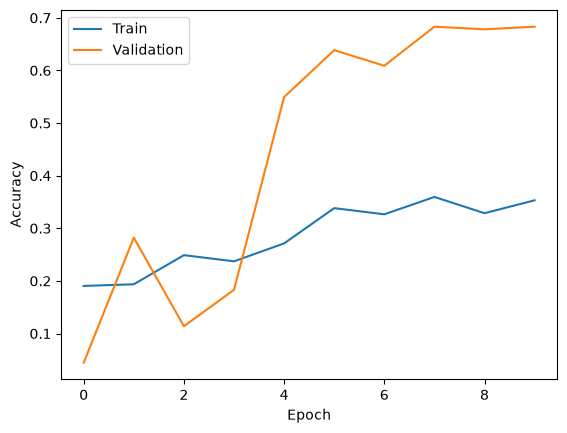

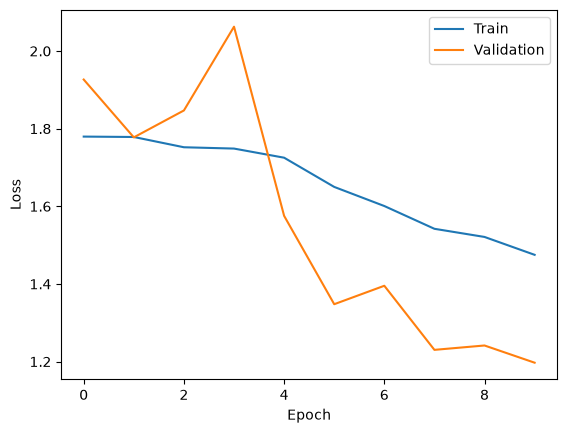

In [70]:
import matplotlib.pyplot as plt

plt.plot(history_C["train_acc"], label="Train")
plt.plot(history_C["val_acc"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history_C["train_loss"], label="Train")
plt.plot(history_C["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

- Our model is highly underfitting, suggests that our model is not complex enough to capture the details

### Making our CNN More Complex

In [90]:
class ComplexCNN(nn.Module):

    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(

        # Block 1
        nn.Conv2d(1, 32, 3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),

        nn.Conv2d(32, 32, 3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),

        nn.MaxPool2d(kernel_size=2, stride=2),

        # Block 2
        nn.Conv2d(32, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),

        nn.Conv2d(64, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),

        nn.MaxPool2d(kernel_size=2, stride=2),

        # Block 3
        nn.Conv2d(64, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),

        nn.Conv2d(128, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),

        nn.MaxPool2d(kernel_size=2, stride=2),

        # Block 4
        nn.Conv2d(128, 256, 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),

        nn.Conv2d(256, 256, 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),

        nn.MaxPool2d(kernel_size=2, stride=2)
    )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            # nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            # nn.Dropout(0.3),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [91]:
model_D = ComplexCNN(num_classes=6).to(device)

criterion_D = nn.CrossEntropyLoss()

optimizer_D = torch.optim.Adam(
    model_D.parameters(),
    lr=1e-3
)

In [ ]:
# ! pip install torchsummary
from torchsummary import summary

summary(model_D , input_size = (1,224,224))

  Using cached torchsummary-1.5.1-py3-none-any.whl.metadata (296 bytes)
Using cached torchsummary-1.5.1-py3-none-any.whl (2.8 kB)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             320
       BatchNorm2d-2         [-1, 32, 224, 224]              64
              ReLU-3         [-1, 32, 224, 224]               0
            Conv2d-4         [-1, 32, 224, 224]           9,248
       BatchNorm2d-5         [-1, 32, 224, 224]              64
              ReLU-6         [-1, 32, 224, 224]               0
         MaxPool2d-7         [-1, 32, 112, 112]               0
            Conv2d-8         [-1, 64, 112, 112]          18,496
       BatchNorm2d-9         [-1, 64, 112, 112]             128
             ReLU-10         [-1, 64, 112, 112]               0
           Conv2d-11         [-1, 64, 112, 112]          36,928
      BatchNorm2d-12         [-1, 64,

In [95]:
history_D = train_model(
    model=model_D,
    train_loader=train_loader_C,
    val_loader=val_loader_C,
    criterion=criterion_D,
    optimizer=optimizer_D,
    device=device,
    epochs=50,
    save_path="complex_cnn.pth"
)

Epoch [1/50] | Train Loss: 1.5144 | Train Acc: 0.3628 | Val Loss: 1.1072 | Val Acc: 0.7079
Epoch [2/50] | Train Loss: 1.3509 | Train Acc: 0.4564 | Val Loss: 1.3293 | Val Acc: 0.6832
Epoch [3/50] | Train Loss: 1.3498 | Train Acc: 0.4532 | Val Loss: 1.2116 | Val Acc: 0.6436
Epoch [4/50] | Train Loss: 1.2487 | Train Acc: 0.5053 | Val Loss: 1.0983 | Val Acc: 0.7079
Epoch [5/50] | Train Loss: 1.1604 | Train Acc: 0.5372 | Val Loss: 1.6882 | Val Acc: 0.5149
Epoch [6/50] | Train Loss: 1.1255 | Train Acc: 0.5606 | Val Loss: 1.2736 | Val Acc: 0.6287
Epoch [7/50] | Train Loss: 1.1238 | Train Acc: 0.5574 | Val Loss: 1.2148 | Val Acc: 0.6238
Epoch [8/50] | Train Loss: 1.0248 | Train Acc: 0.6128 | Val Loss: 1.3353 | Val Acc: 0.5842
Epoch [9/50] | Train Loss: 1.0267 | Train Acc: 0.6000 | Val Loss: 1.1550 | Val Acc: 0.6733
Epoch [10/50] | Train Loss: 0.9413 | Train Acc: 0.6489 | Val Loss: 1.2511 | Val Acc: 0.6238
Epoch [11/50] | Train Loss: 0.8133 | Train Acc: 0.7053 | Val Loss: 1.1456 | Val Acc: 0.71

In [99]:
model_D.load_state_dict(
    torch.load(
        "complex_cnn.pth",
        map_location=device
    )
)

model_D.to(device)

ComplexCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, k

In [100]:
results_D = evaluate_model(
    model_D,
    test_loader_C,
    device,
    classes
)

Accuracy:          0.8366
Balanced Accuracy: 0.5396
MCC:               0.6249

Classification Report:

              precision    recall  f1-score   support

 MT_Blowhole     1.0000    0.6667    0.8000        18
    MT_Break     0.0000    0.0000    0.0000        12
    MT_Crack     0.7778    0.7778    0.7778         9
     MT_Fray     1.0000    0.4000    0.5714         5
     MT_Free     0.8208    0.9930    0.8987       143
   MT_Uneven     1.0000    0.4000    0.5714        15

    accuracy                         0.8366       202
   macro avg     0.7664    0.5396    0.6032       202
weighted avg     0.8038    0.8366    0.7988       202



d:\Study\Deep_Learning\Pytorch_Course\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Study\Deep_Learning\Pytorch_Course\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Study\Deep_Learning\Pytorch_Course\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

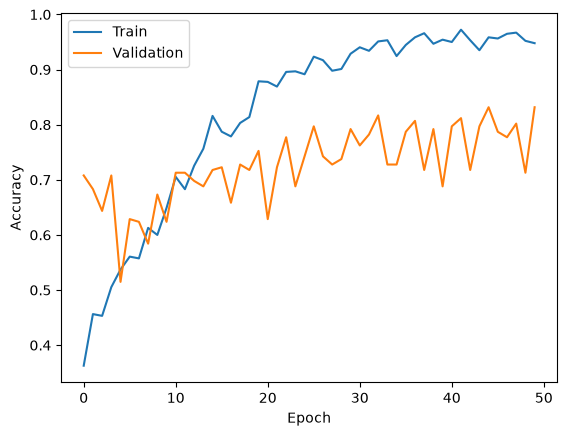

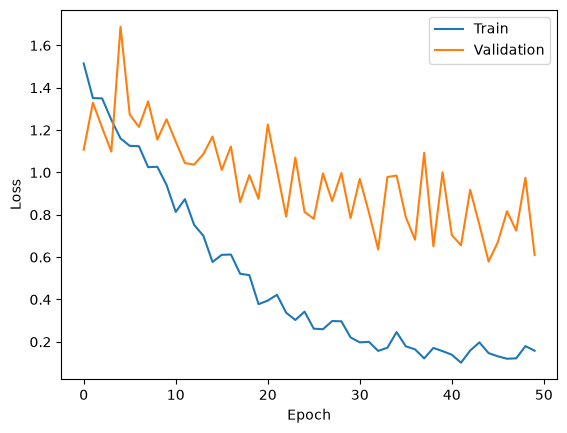

In [101]:
import matplotlib.pyplot as plt

plt.plot(history_D["train_acc"], label="Train")
plt.plot(history_D["val_acc"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history_D["train_loss"], label="Train")
plt.plot(history_D["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Observations:
- Experiment D was extended to 50 epochs without dropout while retaining defect-focused augmentation and balanced sampling. The model achieved 83.66% accuracy, 53.96% balanced accuracy, 60.32% macro F1, and an MCC of 0.6249. The model successfully learned several defect classes, particularly MT_Blowhole and MT_Crack, while MT_Break remained completely undetected. Although the model achieved substantially better multiclass performance than the earlier experiments, the large increase in training accuracy and fluctuating validation performance indicated overfitting. These results demonstrate that the custom CNN has sufficient capacity to learn meaningful defect representations, but further optimization of the training configuration is warranted.I

- But before this, I want to conduct one last experiment by Using Hyperparameter tuning using Optuna on the Experiment D data, to see if changing metrics like learning rate, optimizers, weight decay, dropouts, etc changes anything positively in our results